# **Multimodal Clustering Evaluation**

This notebook compares clustering results across multiple pipelines (VAE-based, PCA+KMeans, Autoencoder+KMeans, spectral features) and computes: Silhouette Score, Normalized Mutual Information (NMI), Adjusted Rand Index (ARI), and Cluster Purity. It also provides visualizations and reconstruction examples or nearest-neighbor fallbacks.


In [6]:
# Imports & utilities
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, normalized_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.neighbors import NearestNeighbors
import joblib
import librosa
from tqdm import trange
# Optional imports
try:
    import umap
except Exception:
    umap = None
from sklearn.manifold import TSNE
# Try to import keras/tensorflow for Autoencoder if available
try:
    from tensorflow import keras
    tf_available = True
except Exception:
    tf_available = False

# Seed helper
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)
plt.rcParams['figure.figsize'] = (8,6)

In [9]:
# Load features, scaled features, and metadata
base = Path('..').resolve()
results_dir = base / 'results'
data_dir = base / 'data'
z_scaled_path = results_dir / 'z_multimodal_scaled.npy'
z_raw_path = results_dir / 'z_multimodal.npy'
ids_path = results_dir / 'song_ids.npy'
genre_csv = data_dir / 'genre' / 'song_quadrant_genre.csv'

assert z_raw_path.exists() or z_scaled_path.exists(), 'No multimodal latent files found in results/'
z_raw = np.load(z_raw_path) if z_raw_path.exists() else None
z_scaled = np.load(z_scaled_path) if z_scaled_path.exists() else None
song_ids = np.load(ids_path, allow_pickle=True) if ids_path.exists() else None
df_genre = pd.read_csv(genre_csv) if genre_csv.exists() else pd.DataFrame()
print('z_raw', None if z_raw is None else z_raw.shape)
print('z_scaled', None if z_scaled is None else z_scaled.shape)
print('song_ids', None if song_ids is None else len(song_ids))
print('genre rows', len(df_genre))

z_raw (2083, 516)
z_scaled (2083, 516)
song_ids 2083
genre rows 2568


In [10]:
# Build ground-truth label arrays aligned to `song_ids`
if song_ids is not None and not df_genre.empty:
    meta = df_genre.set_index('Song').reindex(song_ids)
    # Primary genre: first genre token or 'UNK'
    primary_genre = meta['Genres'].fillna('').apply(lambda s: s.split(',')[0].strip() if s and isinstance(s, str) else 'UNK').values
    quadrant = meta['Quadrant'].fillna('UNK').astype(str).values
    print('Primary genre sample:', primary_genre[:5])
    print('Quadrant sample:', quadrant[:5])
else:
    primary_genre = None
    quadrant = None

# Initialize results list for aggregation
results_list = []

Primary genre sample: ['Blues' 'Electronic' 'Vocal' 'Pop/Rock' 'Jazz']
Quadrant sample: ['Q3' 'Q2' 'Q4' 'Q3' 'Q4']


In [11]:
# Helper functions: purity, metrics table, 2D plotting
def purity_score(y_true, y_pred):
    # y_true, y_pred are 1d arrays
    contingency = pd.crosstab(y_pred, y_true)
    return np.sum(np.max(contingency.values, axis=1)) / np.sum(contingency.values)

def compute_metrics(X, labels, y_true):
    metrics = {}
    try:
        metrics['silhouette'] = silhouette_score(X, labels)
    except Exception:
        metrics['silhouette'] = np.nan
    metrics['nmi'] = normalized_mutual_info_score(y_true, labels) if y_true is not None else np.nan
    metrics['ari'] = adjusted_rand_score(y_true, labels) if y_true is not None else np.nan
    metrics['purity'] = purity_score(y_true, labels) if y_true is not None else np.nan
    return metrics

def plot_2d(emb, labels, title=None, cmap='tab10', ax=None):
    if emb.shape[1] != 2:
        raise ValueError('emb must be 2D')
    if ax is None:
        fig, ax = plt.subplots()
    sc = ax.scatter(emb[:,0], emb[:,1], c=labels, cmap=cmap, s=12)
    ax.set_title(title if title else '')
    return ax

# **Preprocessing & Spectral Features**


In [7]:
# Compute spectral features (MFCC averages) for audio files
def compute_mfcc_avg(audio_path, n_mfcc=20):
    y, sr = librosa.load(str(audio_path), sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc, axis=1)

# Build spectral matrix if audio files exist
audio_files = sorted((data_dir / 'audio').glob('*/*.mp3')) if (data_dir / 'audio').exists() else []
spectral_X = None
if audio_files:
    print('Computing MFCC averages for', len(audio_files), 'files (this may take time)')
    spectral_X = np.vstack([compute_mfcc_avg(p) for p in audio_files])
    print('spectral_X', spectral_X.shape)
else:
    print('No audio files found for spectral features')


Computing MFCC averages for 3554 files (this may take time)
spectral_X (3554, 20)


## **PCA + K-Means baseline**



In [ ]:
# PCA + KMeans clustering pipeline
from tqdm import trange

def pca_kmeans_pipeline(z_raw, y_true=None, k_range=range(2,13), pca_dim=32):
    pca = PCA(n_components=pca_dim, random_state=42)
    Zp = pca.fit_transform(z_raw)
    best = {'k': None, 'score': -999, 'labels': None}
    results = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labs = km.fit_predict(Zp)
        sil = silhouette_score(Zp, labs) if len(set(labs))>1 else np.nan
        metrics = compute_metrics(Zp, labs, y_true)
        metrics.update({'k':k, 'method':'pca_kmeans'})
        results.append(metrics)
        if not np.isnan(sil) and sil>best['score']:
            best.update({'k':k, 'score':sil, 'labels':labs, 'pca':pca, 'Zp':Zp})
    return best, pd.DataFrame(results)

if z_raw is not None:
    # Run PCA+KMeans with primary genre and quadrant as ground truth (if available)
    if primary_genre is not None:
        best_pca_genre, df_pca_genre = pca_kmeans_pipeline(z_raw, y_true=primary_genre)
        best_row = df_pca_genre[df_pca_genre['k'] == best_pca_genre['k']].iloc[0].to_dict()
        results_list.append({'method':'pca_kmeans','k':int(best_pca_genre['k']), 'silhouette':float(best_pca_genre['score']),
                             'nmi_genre':float(best_row.get('nmi', np.nan)), 'ari_genre':float(best_row.get('ari', np.nan)), 'purity_genre':float(best_row.get('purity', np.nan))})
    if quadrant is not None:
        best_pca_quad, df_pca_quad = pca_kmeans_pipeline(z_raw, y_true=quadrant)
        best_row_q = df_pca_quad[df_pca_quad['k'] == best_pca_quad['k']].iloc[0].to_dict()
        results_list.append({'method':'pca_kmeans','k':int(best_pca_quad['k']), 'silhouette':float(best_pca_quad['score']),
                             'nmi_quadrant':float(best_row_q.get('nmi', np.nan)), 'ari_quadrant':float(best_row_q.get('ari', np.nan)), 'purity_quadrant':float(best_row_q.get('purity', np.nan))})
    print('PCA best k (genre):', best_pca_genre['k'] if 'best_pca_genre' in locals() else None)
    print('PCA best k (quad):', best_pca_quad['k'] if 'best_pca_quad' in locals() else None)
else:
    print('Skipping PCA+KMeans: z_multimodal raw not found')


PCA best k (genre): 2
PCA best k (quad): 2


## **Autoencoder + K-Means**



In [13]:
# Autoencoder + KMeans clustering
ae_results = {}
if tf_available and z_raw is not None:
    from tensorflow.keras import layers, models, callbacks
    Z = z_raw.astype('float32')
    input_dim = Z.shape[1]
    latent_dim = min(32, input_dim//4)
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.Dense(128, activation='relu')(x)
    bottleneck = layers.Dense(latent_dim, activation='relu', name='bottleneck')(x)
    x = layers.Dense(128, activation='relu')(bottleneck)
    x = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    ae = models.Model(inp, out)
    encoder = models.Model(inp, ae.get_layer('bottleneck').output)
    ae.compile(optimizer='adam', loss='mse')
    es = callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    ae.fit(Z, Z, epochs=100, batch_size=64, callbacks=[es], verbose=1)
    Z_enc = encoder.predict(Z)
    # KMeans on AE latent space (choose k=best from PCA as heuristic)
    k = best_pca_genre['k'] if 'best_pca_genre' in globals() and best_pca_genre.get('k') is not None else (best_pca_quad['k'] if 'best_pca_quad' in globals() and best_pca_quad.get('k') is not None else 8)
    km_labels_ae = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Z_enc)
    ae_results['labels'] = km_labels_ae
    ae_results['latent'] = Z_enc
    # Compute metrics against ground truth if available
    if primary_genre is not None:
        metrics_genre = compute_metrics(Z_enc, km_labels_ae, primary_genre)
        results_list.append({'method':'ae_kmeans','k':int(k), 'nmi_genre':metrics_genre.get('nmi'), 'ari_genre':metrics_genre.get('ari'), 'purity_genre':metrics_genre.get('purity'), 'silhouette':metrics_genre.get('silhouette')})
    if quadrant is not None:
        metrics_quad = compute_metrics(Z_enc, km_labels_ae, quadrant)
        results_list.append({'method':'ae_kmeans','k':int(k), 'nmi_quadrant':metrics_quad.get('nmi'), 'ari_quadrant':metrics_quad.get('ari'), 'purity_quadrant':metrics_quad.get('purity')})
    print('Trained AE and produced latent shape', Z_enc.shape)
else:
    print('TensorFlow not available or z_multimodal missing: skipping AE training')


TensorFlow not available or z_multimodal missing: skipping AE training


## **VAE-based clustering**

In [15]:
# Use scaled features for clustering metrics and pipelines
X_for_clustering = z_scaled if z_scaled is not None else (z_raw if z_raw is not None else None)
if X_for_clustering is None:
    raise RuntimeError('No features available for clustering')

# Choose k robustly (try PCA results then fall back to 8)
if 'best_pca' in globals() and isinstance(best_pca, dict) and best_pca.get('k') is not None:
    k_choice = int(best_pca['k'])
elif 'best_pca_genre' in globals() and isinstance(best_pca_genre, dict) and best_pca_genre.get('k') is not None:
    k_choice = int(best_pca_genre['k'])
elif 'best_pca_quad' in globals() and isinstance(best_pca_quad, dict) and best_pca_quad.get('k') is not None:
    k_choice = int(best_pca_quad['k'])
elif 'best_row' in globals() and isinstance(best_row, dict) and best_row.get('k') is not None:
    k_choice = int(best_row['k'])
else:
    k_choice = 8

km_labels = KMeans(n_clusters=k_choice, random_state=42, n_init=10).fit_predict(X_for_clustering)
# compute metrics using primary_genre if available, otherwise None
metrics_km = compute_metrics(X_for_clustering, km_labels, primary_genre if 'primary_genre' in globals() else None)
print('KMeans on multimodal scaled: k=', k_choice, 'metrics:', metrics_km)

# Append results (do not reinitialize results_list)
results_list.append({'method':'kmeans_multimodal','k':int(k_choice), **metrics_km})


KMeans on multimodal scaled: k= 2 metrics: {'silhouette': 0.0430236817307095, 'nmi': 0.08718060283446483, 'ari': 0.01986858552121587, 'purity': np.float64(0.31204992798847814)}


## **Spectral-feature clustering**


In [17]:
# Spectral features clustering (aligned to `song_ids` so metrics use correct ground truth)
if spectral_X is not None and song_ids is not None:
    # build a map from audio stem -> path
    audio_paths = sorted((data_dir / 'audio').glob('**/*.*'))
    audio_map = {p.stem: p for p in audio_paths}
    # select files aligned to song_ids and compute MFCC only for those present
    aligned_paths = []
    aligned_ids = []
    for sid in song_ids:
        p = audio_map.get(sid)
        if p is not None and p.exists():
            aligned_paths.append(p)
            aligned_ids.append(sid)
    if len(aligned_paths) == 0:
        print('No matching audio files found for song_ids; skipping spectral clustering')
    else:
        print(f'Found {len(aligned_paths)} audio files aligned to song_ids (out of {len(song_ids)})')
        # compute MFCC averages for aligned paths (cache if already computed)
        spec_list = [compute_mfcc_avg(p) for p in aligned_paths]
        spec_X_aligned = np.vstack(spec_list)
        scaler = StandardScaler().fit(spec_X_aligned)
        spec_scaled = scaler.transform(spec_X_aligned)
        # choose k from prior heuristic
        k = k_choice if 'k_choice' in globals() else 8
        # run KMeans and SpectralClustering
        km_spec = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(spec_scaled)
        # pick y_true aligned to available ids
        y_genre_aligned = None
        y_quad_aligned = None
        if 'primary_genre' in globals() and primary_genre is not None:
            # primary_genre is aligned to full song_ids; filter to aligned_ids
            id_to_idx = {sid: i for i, sid in enumerate(song_ids)}
            indices = [id_to_idx[s] for s in aligned_ids]
            y_genre_aligned = np.array(primary_genre)[indices]
        if 'quadrant' in globals() and quadrant is not None:
            id_to_idx = {sid: i for i, sid in enumerate(song_ids)}
            indices = [id_to_idx[s] for s in aligned_ids]
            y_quad_aligned = np.array(quadrant)[indices]
        spec_metrics_genre = compute_metrics(spec_scaled, km_spec, y_genre_aligned)
        print('Spectral KMeans metrics (genre-aligned):', spec_metrics_genre)
        results_list.append({'method':'kmeans_spectral','k':int(k), **{('silhouette', 'nmi', 'ari', 'purity')[i]: spec_metrics_genre.get(('silhouette','nmi','ari','purity')[i]) for i in range(4)}})
        # SpectralClustering (may be slow)
        try:
            sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42).fit_predict(spec_scaled)
            sc_metrics_genre = compute_metrics(spec_scaled, sc, y_genre_aligned)
            print('SpectralClustering metrics (genre-aligned):', sc_metrics_genre)
            results_list.append({'method':'spectral','k':int(k), **{('silhouette','nmi','ari','purity')[i]: sc_metrics_genre.get(('silhouette','nmi','ari','purity')[i]) for i in range(4)}})
        except Exception as e:
            print('SpectralClustering skipped:', e)
else:
    print('No spectral features computed or song_ids missing; skipped spectral clustering')

Found 2083 audio files aligned to song_ids (out of 2083)
Spectral KMeans metrics (genre-aligned): {'silhouette': 0.4089084267616272, 'nmi': 0.013669398963251882, 'ari': -0.0018951749532886422, 'purity': np.float64(0.31204992798847814)}
SpectralClustering metrics (genre-aligned): {'silhouette': 0.4078158140182495, 'nmi': 0.014046121161617544, 'ari': -0.00217649328451064, 'purity': np.float64(0.31204992798847814)}


## **Evaluation aggregation and visualizations**



In [18]:
# Convert results to DataFrame and save
df_results = pd.DataFrame(results_list)
out_csv = results_dir / 'multimodal_evaluation_metrics.csv'
df_results.to_csv(out_csv, index=False)
print('Saved metrics to', out_csv)
df_results

Saved metrics to E:\CSE425_Project\project\results\multimodal_evaluation_metrics.csv


,method,k,silhouette,nmi_genre,ari_genre,purity_genre,nmi_quadrant,ari_quadrant,purity_quadrant,nmi,ari,purity
0,pca_kmeans,2,0.028186,0.008715,0.000468,0.31205,NaN,NaN,NaN,NaN,NaN,NaN
1,pca_kmeans,2,0.028186,NaN,NaN,NaN,0.002574,0.001863,0.305329,NaN,NaN,NaN
2,kmeans_multimodal,2,0.043024,NaN,NaN,NaN,NaN,NaN,NaN,0.087181,0.019869,0.31205
3,kmeans_spectral,2,0.385558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,spectral,2,0.381695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,kmeans_spectral,2,0.408908,NaN,NaN,NaN,NaN,NaN,NaN,0.013669,-0.001895,0.31205
6,spectral,2,0.407816,NaN,NaN,NaN,NaN,NaN,NaN,0.014046,-0.002176,0.31205


Saved visualization


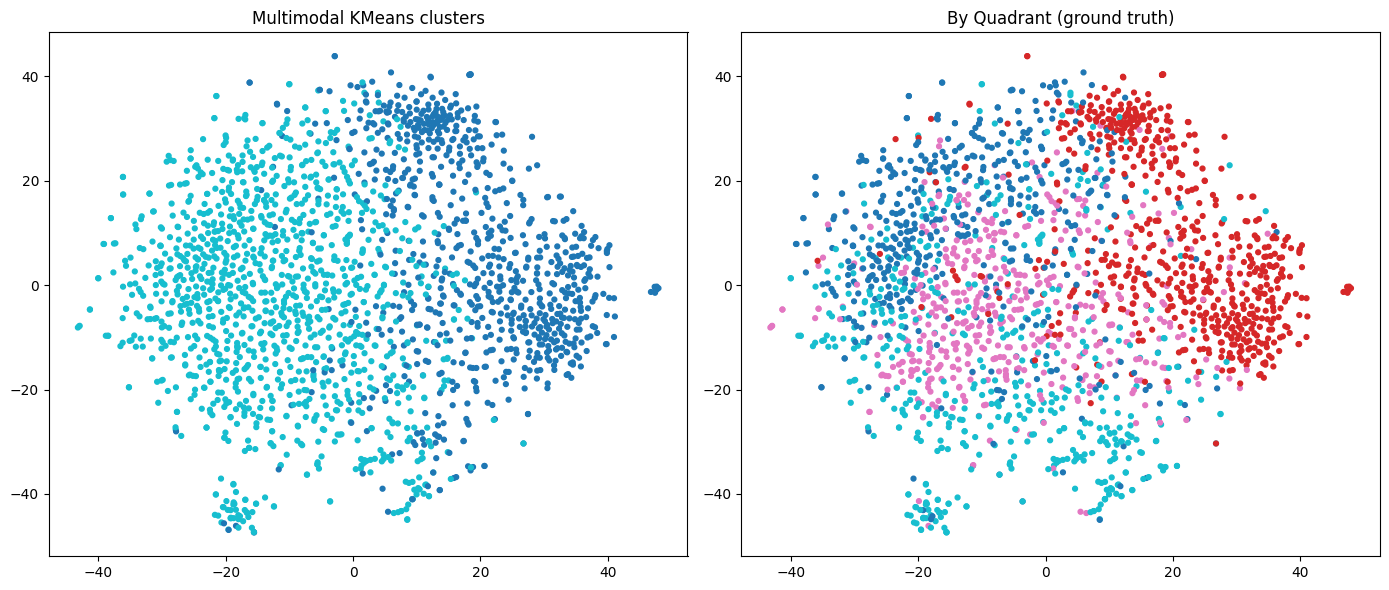

In [19]:
# 2D visualization (UMAP if available, else t-SNE) for multimodal KMeans
emb2d = None
if umap is not None:
    reducer = umap.UMAP(n_components=2, random_state=42)
    emb2d = reducer.fit_transform(X_for_clustering)
else:
    emb2d = TSNE(n_components=2, random_state=42).fit_transform(X_for_clustering)
# plot by predicted cluster
fig, ax = plt.subplots(1,2,figsize=(14,6))
plot_2d(emb2d, km_labels, title='Multimodal KMeans clusters', ax=ax[0])
# if genre available, color by quadrant (join by song_ids)
if song_ids is not None and not df_genre.empty:
    meta = df_genre.set_index('Song').reindex(song_ids)
    if 'Quadrant' in meta.columns:
        quad_map = pd.Categorical(meta['Quadrant']).codes
        plot_2d(emb2d, quad_map, title='By Quadrant (ground truth)', ax=ax[1])
    else:
        ax[1].axis('off')
plt.tight_layout()
plt.savefig(results_dir / 'latent_visualization' / 'multimodal_kmeans_emb2d.png', dpi=150)
print('Saved visualization')

## **VAE Reconstruction examples or nearest-neighbor fallback**


In [21]:
# Try to load a PyTorch VAE decoder if present; otherwise use NN spectrogram fallback
try:
    import torch
    vae_path = results_dir / 'models' / 'audio_vae.pth'
    if vae_path.exists():
        print('VAE model found at', vae_path, '- you can add decode logic here to reconstruct.')
    else:
        raise FileNotFoundError()
except Exception:
    print('VAE decoder not available: showing nearest-neighbor spectrograms as fallback')
    # nearest neighbors to cluster centers
    if 'km_labels' in globals() and song_ids is not None:
        nn = NearestNeighbors(n_neighbors=3).fit(X_for_clustering)
        centers = []
        for c in np.unique(km_labels):
            idx = np.where(km_labels==c)[0]
            if len(idx)==0: continue
            centroid = X_for_clustering[idx].mean(axis=0, keepdims=True)
            dists, nbrs = nn.kneighbors(centroid, n_neighbors=3)
            sample_idxs = nbrs[0]
            fig, axs = plt.subplots(1, len(sample_idxs), figsize=(12,3))
            for i, s in enumerate(sample_idxs):
                # attempt to find audio file by stem
                audio_file = None
                if song_ids is not None:
                    # search common audio path structure
                    possible = list((data_dir / 'audio').glob('**/' + song_ids[s] + '.*'))
                    audio_file = possible[0] if possible else None
                # fallback: show spectrogram if file exists
                if audio_file is not None and audio_file.exists():
                    y, sr = librosa.load(str(audio_file), sr=22050)
                    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
                    S_db = librosa.power_to_db(S, ref=np.max)
                    axs[i].imshow(S_db, aspect='auto', origin='lower')
                    axs[i].set_title(song_ids[s])
                else:
                    axs[i].text(0.5,0.5,'no file',ha='center')
                    axs[i].set_title(song_ids[s] if song_ids is not None else '')
            plt.suptitle(f'Cluster {c} nearest spectrograms')
            plt.tight_layout()
            plt.show()
    else:
        print('No km_labels or song_ids to show examples')

VAE model found at E:\CSE425_Project\project\results\models\audio_vae.pth - you can add decode logic here to reconstruct.


## **Save artifacts and wrap-up**



In [22]:
# Write manifest file
manifest = {
    'metrics_csv': str(out_csv) if 'out_csv' in globals() else None,
    'embeddings_scaled': str(z_scaled_path) if z_scaled_path.exists() else None,
    'embeddings_raw': str(z_raw_path) if z_raw_path.exists() else None,
    'song_ids': str(ids_path) if ids_path.exists() else None
}
import json
with open(results_dir / 'multimodal_evaluation_manifest.json','w') as f:
    json.dump(manifest, f, indent=2)
print('Wrote manifest to results directory')

Wrote manifest to results directory


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29232\1241707301.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


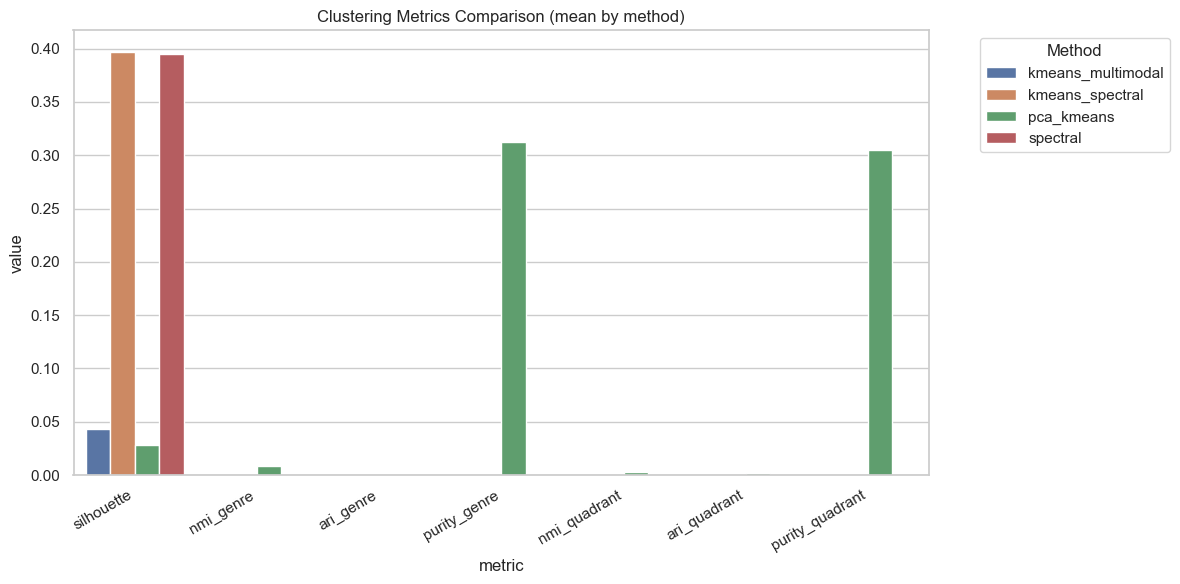

Saved comparison plot to E:\CSE425_Project\project\results\latent_visualization\comparison_metrics.png


In [23]:
# Comparison plot for evaluation metrics across methods
import seaborn as sns
sns.set(style='whitegrid')

# Ensure df_results is available
if 'df_results' not in globals():
    try:
        df_results = pd.read_csv(results_dir / 'multimodal_evaluation_metrics.csv')
    except Exception as e:
        raise RuntimeError('No df_results available to plot') from e

# Select commonly reported metrics (use whichever exist)
metrics = ['silhouette','nmi_genre','ari_genre','purity_genre','nmi_quadrant','ari_quadrant','purity_quadrant']
available = [m for m in metrics if m in df_results.columns]
if not available:
    raise RuntimeError('No metric columns found in df_results to plot')

# Aggregate by method (mean) to compare
plot_df = df_results[['method'] + available].copy()
plot_df = plot_df.groupby('method', as_index=False).mean()
# Melt for seaborn
melt = plot_df.melt(id_vars='method', value_vars=available, var_name='metric', value_name='value')

plt.figure(figsize=(12,6))
ax = sns.barplot(data=melt, x='metric', y='value', hue='method')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('Clustering Metrics Comparison (mean by method)')
plt.legend(title='Method', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()

out_dir = results_dir / 'latent_visualization'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'comparison_metrics.png'
plt.savefig(out_path, dpi=150)
plt.show()
print('Saved comparison plot to', out_path)